In [21]:
# 1. Install necessary library for data splitting
!pip install split-folders

import os
import zipfile
import splitfolders
import shutil

# --- Setup: Auto-Extract Dataset ---
# Check if extraction is needed
if not os.path.exists('dataset_root'):
    print("Initiating dataset setup...")
    os.makedirs('dataset_root', exist_ok=True)

    # Locate uploaded zip file
    zip_files = [f for f in os.listdir('.') if f.endswith('.zip')]

    if zip_files:
        print(f"Extracting archive: {zip_files[0]}...")
        with zipfile.ZipFile(zip_files[0], 'r') as zip_ref:
            zip_ref.extractall('dataset_root')
        print("Extraction complete.")
    else:
        print("Warning: No .zip file found. Ensure dataset is uploaded.")

# --- Core Logic: Locate & Split Data ---

# 2. Reset output directory to ensure a clean state
if os.path.exists('output_dataset'):
    shutil.rmtree('output_dataset')

print("Scanning directory structure...")

# 3. Heuristic search for the valid dataset root (containing class folders)
real_base_dir = None
for root, dirs, files in os.walk('dataset_root'):
    # Check for image files in current directory
    images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # If images found, set the parent directory as the base
    if len(images) > 0:
        print(f"✅ Images detected in: {root}")
        real_base_dir = os.path.dirname(root)
        break

if real_base_dir:
    print(f"🎯 Target dataset root identified: {real_base_dir}")

    # 4. Execute Split: 80% Training, 20% Validation
    # Generates 'output_dataset/train' and 'output_dataset/val'
    splitfolders.ratio(real_base_dir, output="output_dataset", seed=1337, ratio=(.8, .2), group_prefix=None)

    # Define paths for downstream generators
    train_dir = 'output_dataset/train'
    val_dir = 'output_dataset/val'
    print("\n👍 Success: Dataset split complete. Ready for model training.")

else:
    print("❌ Error: No valid image structure found.")
    print("Directory tree for debugging:")
    for root, dirs, files in os.walk('dataset_root'):
        level = root.replace('dataset_root', '').count(os.sep)
        print(f"{' ' * 4 * level}{os.path.basename(root)}/")

Scanning directory structure...
✅ Images detected in: dataset_root/train/Open_Eyes
🎯 Target dataset root identified: dataset_root/train


Copying files: 4000 files [00:00, 8263.67 files/s]


👍 Success: Dataset split complete. Ready for model training.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths for the split dataset
train_dir = 'output_dataset/train'
val_dir = 'output_dataset/val'

# --- Training Generator (With Augmentation) ---
# Apply data augmentation to improve generalization and prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),   # Ensure this matches the model input shape
    batch_size=32,
    class_mode='binary',    # Use 'categorical' if more than 2 classes
    color_mode='grayscale', # Set to grayscale based on model requirements
    shuffle=True
)

# --- Validation Generator (Raw Data) ---
# Only rescale pixel values; no augmentation to ensure fair evaluation
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False  # Shuffling is not required for validation/testing
)

Found 3200 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- Model Architecture Definition ---
model = Sequential([
    # Convolutional Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D(2, 2),
    Dropout(0.25),  # Dropout to reduce overfitting

    # Convolutional Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Convolutional Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.4),   # Higher dropout for deeper layers

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),   # 50% dropout in the dense layer
    Dense(1, activation='sigmoid') # Sigmoid activation for binary output (0 or 1)
])

# --- Model Compilation ---
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- Callbacks ---
# Stop training early if validation loss does not improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# --- Training Execution ---
print("Starting Training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop]
)

جاري بدء التدريب الحقيقي...
Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 256ms/step - accuracy: 0.6168 - loss: 0.6077 - val_accuracy: 0.8512 - val_loss: 0.2901
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 258ms/step - accuracy: 0.8468 - loss: 0.3498 - val_accuracy: 0.9500 - val_loss: 0.1617
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 253ms/step - accuracy: 0.8966 - loss: 0.2650 - val_accuracy: 0.9425 - val_loss: 0.1391
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 254ms/step - accuracy: 0.9015 - loss: 0.2419 - val_accuracy: 0.9575 - val_loss: 0.1122
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 253ms/step - accuracy: 0.9322 - loss: 0.1695 - val_accuracy: 0.9663 - val_loss: 0.1086
Epoch 6/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 253ms/step - accuracy: 0.9201 - loss: 0.1966 - val_accuracy: 0.9500 - val_loss: 0.1228
Epoch 7/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 254ms/step - accuracy: 0.9303 - loss: 0.1802 - val_accuracy: 0.9525 - val_loss: 0.0967
Epoch 8/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 255ms/step 

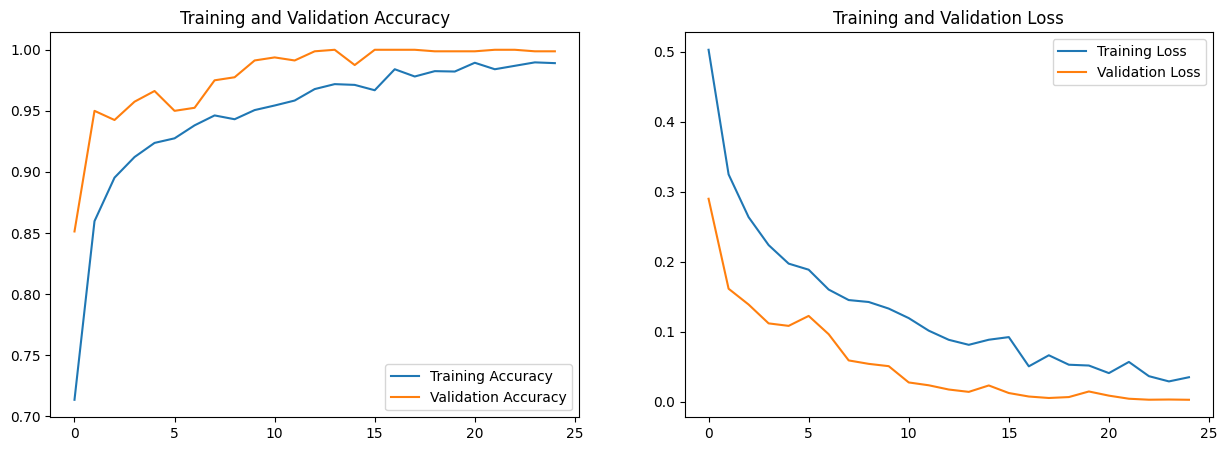

In [ ]:
import matplotlib.pyplot as plt


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

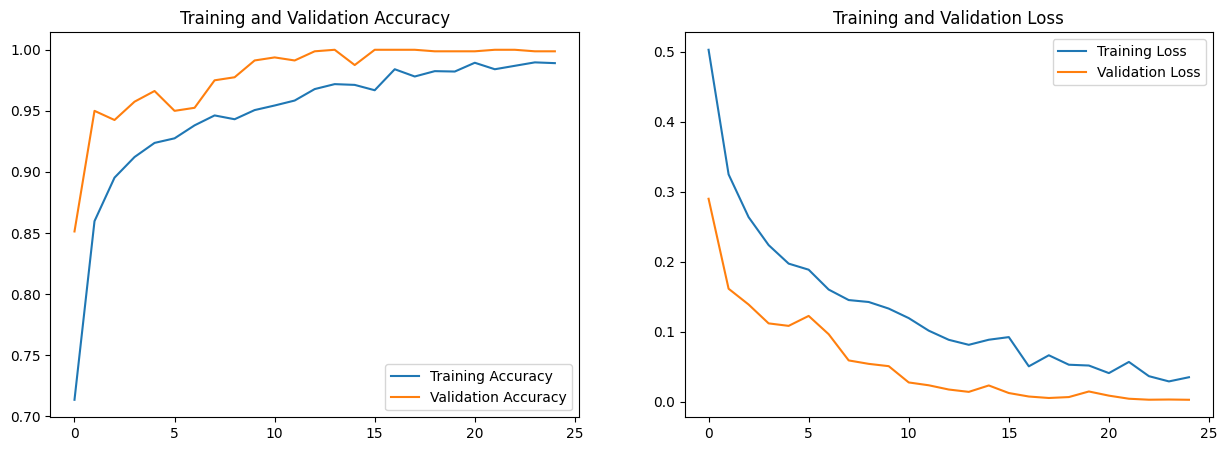

Generating predictions...
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step

--- Classification Report ---
              precision    recall  f1-score   support

 Closed_Eyes       1.00      1.00      1.00       400
   Open_Eyes       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



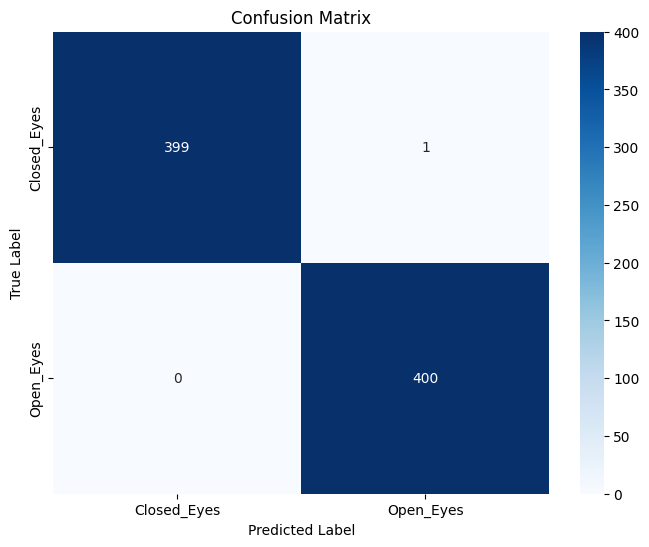


📊 Final Validation Accuracy: 99.87%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- 1. Plotting Training History ---
# Visualize accuracy and loss over epochs to check for overfitting/underfitting
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# --- 2. Evaluation & Confusion Matrix ---

print("Generating predictions...")
# Reset generator to ensure alignment between predictions and ground truth
val_generator.reset()
predictions = model.predict(val_generator)

# Convert probabilities to binary class labels (0 or 1)
predicted_classes = (predictions > 0.5).astype("int32")

# Retrieve ground truth labels
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Print Classification Report (Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Plot Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Final Evaluation on Validation Set
final_loss, final_accuracy = model.evaluate(val_generator, verbose=0)
print(f"\n📊 Final Validation Accuracy: {final_accuracy*100:.2f}%")

In [ ]:
import os
from google.colab import files

# --- Save and Download Model ---

# 1. Save the model locally in the current environment (H5 format)
model_name = 'my_best_eye_model.h5'
model.save(model_name)
print(f"✅ Model successfully saved as: {model_name}")

# 2. Download the model file to your local machine
print("Initiating download...")
files.download(model_name)

✅ Model successfully saved as: my_best_eye_model.h5
Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>